# Project - Recommendation System

In [1]:
%matplotlib inline

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import time
from sklearn.externals import joblib
import Recommenders as Recommenders
import Evaluation as Evaluation
import matplotlib.pyplot as plt
import seaborn as sns

### Q1. Read and analysies the dataset. 

In [2]:
df = pd.read_csv('ratings_Electronics.csv')
df.columns = ['userid', 'pro_id', 'rating', 'timestamp']

In [3]:
df.head()

,userid,pro_id,rating,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
2,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
3,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
4,A1QGNMC6O1VW39,0511189877,5.0,1397433600


In [4]:
# Check the number of rows and columns
rows, columns = df.shape
print("No of rows: ", rows)
print("No of columns: ", columns)

No of rows:  7824481
No of columns:  4


In [5]:
#Total 7824481 in training data and 4 features

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824481 entries, 0 to 7824480
Data columns (total 4 columns):
userid       object
pro_id       object
rating       float64
timestamp    int64
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


### Cleaning the data

In [7]:
#Check for null values in the dataset
df.isnull().sum()

userid       0
pro_id       0
rating       0
timestamp    0
dtype: int64

In [8]:
### There is no null Value in the columns

In [9]:
#Next, we should check if our dataset has any duplicates rows and drop them:-
duplicateRowsDF = df.duplicated()
print('Total Duplicate Rows except first occurrence based on all columns are : %d' % (duplicateRowsDF.sum()))

Total Duplicate Rows except first occurrence based on all columns are : 0


In [10]:
# Summary statistics of 'rating' variable
df[['rating']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating,7824481.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [11]:
print('The Minimum rating to the product is : %d' %(df['rating'].min()))
print('The Maximum rating to the product is : %d' %(df['rating'].max()))

The Minimum rating to the product is : 1
The Maximum rating to the product is : 5


In [12]:
# Summary statistics of 'rating' variable
carrier_count = df["rating"].value_counts()
carrier_count

5.0    4347540
4.0    1485781
1.0     901765
3.0     633073
2.0     456322
Name: rating, dtype: int64

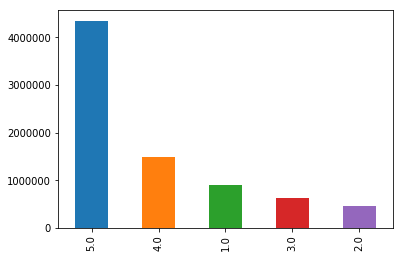

In [13]:
df['rating'].value_counts().plot('bar')

In [14]:
# Number of unique user id and product id in the data
print('Number of unique user id is  ', df['userid'].nunique())
print('Number of unique product id is ', df['pro_id'].nunique())

Number of unique user id is   4201696
Number of unique product id is  476001


## Q2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [15]:
top_rated = df.groupby('userid').size().sort_values(ascending=False)[:10]
top_rated

userid
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
dtype: int64

In [16]:
user_counts = df['userid'].value_counts()
df_r = df[df['userid'].isin(user_counts[user_counts >= 50].index)]

In [17]:
print('Number of users who have rated 50 or more items =', len(df_r))
print('Number of unique user is  ', df_r['userid'].nunique())
print('Number of unique product ID is ', df_r['pro_id'].nunique())

Number of users who have rated 50 or more items = 125871
Number of unique user is   1540
Number of unique product ID is  48190


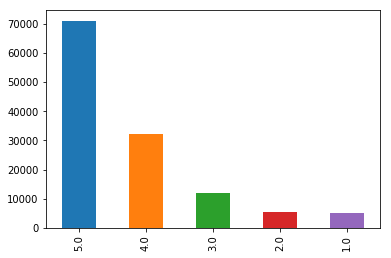

In [18]:
df_r['rating'].value_counts().plot('bar')

In [19]:
#Calculate dense
rating_matrix = df_r.pivot(index = 'userid', columns ='pro_id', values = 'rating').fillna(0)
total_rating_number = rating_matrix.shape[0] * rating_matrix.shape[1]
print ("Total number rating =",total_rating_number)
denser = ( len(df_r)/total_rating_number) * 100 
print ( 'Denser = : %1.2f' % denser , "%")

Total number rating = 74212600
Denser = : 0.17 %


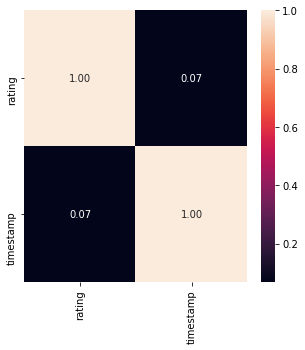

In [20]:
#correlation data
import matplotlib.pyplot as plt
import seaborn as sns
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(df_r.corr(),annot=True,ax=ax,fmt=".2f")
plt.xticks(rotation=90)
plt.show()

In [21]:
# correlection not really useful 

### Q3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [22]:
# timestamp not useful in data. Hence I am droping it
df_r = df_r.drop(["timestamp"],axis=1)

In [23]:
train_data, test_data = train_test_split(df_r, test_size = 0.3, random_state=7)

In [24]:
train_data.head()

,userid,pro_id,rating
1808948,A1RJKTYC03L0JY,B001940MFO,5.0
5681481,A3EZEP0FX5BC1P,B0079TOI8K,4.0
1344930,ASFP250F22MDZ,B000S5KMSW,5.0
5727810,A1XXMNLOLKNO0I,B007F9XHBI,5.0
5957852,AWNBZSEZ9P8BE,B007X3VEX4,4.0


In [25]:
test_data.head()

,userid,pro_id,rating
1106620,A1RPTVW5VEOSI,B000K5VD2E,1.0
7577498,A213J54E63SYOP,B00EYVNFMG,4.0
3628706,A17V9XL4CWTQ6G,B003W5QCTI,4.0
2709000,A3V7D0LH8L7BG0,B002MAPS6W,4.0
1700240,ATNOI7E8GTIVE,B0015A8Y3E,5.0


In [26]:
print(" Train data =", train_data.shape)
print(" Test data =", test_data.shape)

 Train data = (88109, 3)
 Test data = (37762, 3)


In [27]:
train_data.groupby('pro_id')['rating'].mean().head()

pro_id
0594451647    5.000000
0594481813    3.000000
0970407998    2.500000
0972683275    4.750000
1400501466    3.333333
Name: rating, dtype: float64

In [28]:
train_data.groupby('pro_id')['rating'].mean().head().sort_values(ascending=False).head()

pro_id
0594451647    5.000000
0972683275    4.750000
1400501466    3.333333
0594481813    3.000000
0970407998    2.500000
Name: rating, dtype: float64

In [29]:
train_data.groupby('pro_id')['rating'].count().sort_values(ascending=False).head()

pro_id
B0088CJT4U    146
B003ES5ZUU    128
B007WTAJTO    114
B000N99BBC    107
B008DWCRQW    105
Name: rating, dtype: int64

In [30]:
ratings_mean_count = pd.DataFrame(train_data.groupby('pro_id')['rating'].mean())

In [31]:
ratings_mean_count['rating_counts'] = pd.DataFrame(train_data.groupby('pro_id')['rating'].count())

In [32]:
ratings_mean_count.head()

,rating,rating_counts
pro_id,,
0594451647,5.000000,1
0594481813,3.000000,1
0970407998,2.500000,2
0972683275,4.750000,4
1400501466,3.333333,6


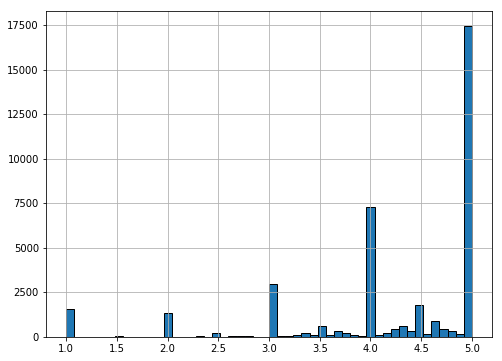

In [33]:
plt.figure(figsize=(8,6))
plt.rcParams['patch.force_edgecolor'] = True
ratings_mean_count['rating'].hist(bins=50)

#### we can see that the integer values have taller bars than the floating values since most of the users assign rating as integer value i.e. 1, 2, 3, 4 or 5. Furthermore, it is evident that the data has a weak normal distribution

C:\Users\apichu\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


<Figure size 576x432 with 0 Axes>

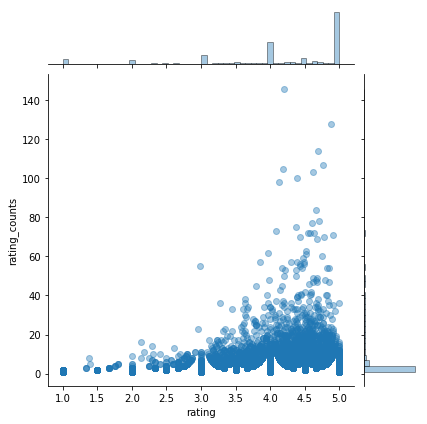

In [34]:
plt.figure(figsize=(8,6))
plt.rcParams['patch.force_edgecolor'] = True
sns.jointplot(x='rating', y='rating_counts', data=ratings_mean_count, alpha=0.4)

The graph shows that, in general, product with higher average ratings actually have more number of ratings, compared with product that have lower average ratings.

### Q4. Build Popularity Recommender model

In [35]:
g_train_data  = train_data.groupby('pro_id').agg({'userid': 'count'}).reset_index()
g_train_data.rename(columns = {'userid': 'usercount'},inplace=True)
g_train_data.head()

,pro_id,usercount
0,0594451647,1
1,0594481813,1
2,0970407998,2
3,0972683275,4
4,1400501466,6


In [36]:
sort_train_data = g_train_data.sort_values(['usercount', 'pro_id'], ascending = [0,1]) 
sort_train_data['rank'] = sort_train_data['usercount'].rank(ascending=0, method='first') 
p_recommendations = sort_train_data.head(5)  # First 5 top rank 
p_recommendations 

,pro_id,usercount,rank
30877,B0088CJT4U,146,1.0
19628,B003ES5ZUU,128,2.0
30281,B007WTAJTO,114,3.0
8677,B000N99BBC,107,4.0
31132,B008DWCRQW,105,5.0


In [37]:
u_id= [10,130,310,140,195]
for user_id in u_id :
    u_recommendations = p_recommendations 
    u_recommendations['userid'] = user_id
    cols = u_recommendations.columns.tolist() 
    cols = cols[-1:] + cols[:-1] 
    u_recommendations = u_recommendations[cols] 
    print("..........................................")
    print("Recommendation for the userId =" , user_id)   
    print("..........................................")
    print(u_recommendations)

..........................................
Recommendation for the userId = 10
..........................................
       userid      pro_id  usercount  rank
30877      10  B0088CJT4U        146   1.0
19628      10  B003ES5ZUU        128   2.0
30281      10  B007WTAJTO        114   3.0
8677       10  B000N99BBC        107   4.0
31132      10  B008DWCRQW        105   5.0
..........................................
Recommendation for the userId = 130
..........................................
       userid      pro_id  usercount  rank
30877     130  B0088CJT4U        146   1.0
19628     130  B003ES5ZUU        128   2.0
30281     130  B007WTAJTO        114   3.0
8677      130  B000N99BBC        107   4.0
31132     130  B008DWCRQW        105   5.0
..........................................
Recommendation for the userId = 310
..........................................
       userid      pro_id  usercount  rank
30877     310  B0088CJT4U        146   1.0
19628     310  B003ES5ZUU        

C:\Users\apichu\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  after removing the cwd from sys.path.


The above Popularity Recommender model is showing same for all the user. It is not personalized. It is purly based on the top rank only. This will be useful only when we dont have much data. 

### Q5. Build Collaborative Filtering model.

In [38]:
# We need the format of ratings matrix to be one row per user and one column per product.
#Fill not available values as 0.0 - sprase martix
R_df = df_r.pivot(index = 'userid', columns ='pro_id', values = 'rating').fillna(0)
R_df.tail()

pro_id,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
userid,,,,,,,,,,,,,,,,,,,,,
AZBXKUH4AIW3X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZCE11PSTCH1L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZMY6E8B52L2T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZNUHQSHZHSUE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZOK5STV85FBJ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
from scipy.sparse.linalg import svds
#singluar value decomposition
#Compute the largest k singular values/vectors for a sparse matrix.
#k: Number of singular values and vectors to compute. Must be 1 <= k < min(R_df.shape)
# R_df is to compute the SVD on
# The singular values - sigma
U, sigma, Vt = svds(R_df, k = 50)

In [40]:
#diag
sigma = np.diag(sigma)

In [41]:
#np.dot - Dot product of two arrays
#I also need to add the user means back to get the predicted 5-star ratings
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) 
preds_df = pd.DataFrame(all_user_predicted_ratings, columns = R_df.columns)

In [42]:
#predictions of  ratings
preds_df.head()

pro_id,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.005086,0.002178,0.003668,-0.040843,0.009640,0.006808,0.020659,0.000649,0.020331,0.005633,...,0.000238,-0.061477,0.001214,-0.123433,0.028490,0.016109,0.002855,-0.174568,0.011367,-0.012997
1,0.002286,-0.010898,-0.000724,0.130259,0.007506,-0.003350,0.063711,-0.000674,0.016111,-0.002433,...,-0.000038,0.013766,0.001473,0.025588,-0.042103,0.004251,0.002177,-0.024362,-0.014765,0.038570
2,-0.001655,-0.002675,-0.007355,0.007264,0.005152,-0.003986,-0.003480,0.006961,-0.006606,-0.002719,...,-0.001708,-0.051040,0.000325,-0.054867,0.017870,-0.004996,-0.002426,0.083928,-0.112205,0.005964
3,0.001856,0.011019,-0.005910,-0.014134,0.000179,0.001877,-0.005391,-0.001709,0.004968,0.001402,...,0.000582,-0.009326,-0.000465,-0.048315,0.023302,0.006790,0.003380,0.005460,-0.015263,-0.025996
4,0.001115,-0.002670,0.011018,0.014434,0.010319,0.006002,0.017151,0.003726,0.001404,0.005645,...,0.000207,0.023761,0.000747,-0.019347,-0.012749,0.001026,0.001364,-0.020580,0.011828,0.012770


In [43]:
sigma

array([[ 66.16942358,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  66.26045906,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,  66.5326469 , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ..., 107.7090351 ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
        119.69501814,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        , 182.29276718]])

In [44]:
def recommend_items(userID, p_df, pr_df, num_r):
    user_idx = userID-1  
    sorted_user_r  = p_df.iloc[user_idx].sort_values(ascending=False)
    sorted_user_p  = pr_df.iloc[user_idx].sort_values(ascending=False)
    temp = pd.concat([sorted_user_r, sorted_user_p], axis=1)
    temp.index.name = 'Recommended Items'
    temp.columns = ['User_ratings', 'User_predictions']
    
    temp = temp.loc[temp.User_ratings == 0]   
    temp = temp.sort_values('User_predictions', ascending=False)
    print('\nBelow are the recommended items for user(user_id = {}):\n'.format(userID))
    print(temp.head(num_recommendations))

In [45]:
userID = 140
num_recommendations = 10
recommend_items(userID, R_df, preds_df, num_recommendations)


Below are the recommended items for user(user_id = 140):

                   User_ratings  User_predictions
Recommended Items                                
B002R5AM7C                  0.0          1.299671
B005HMKKH4                  0.0          1.186321
B00834SJSK                  0.0          1.052076
B0034CL2ZI                  0.0          1.015293
B004T9RR6I                  0.0          0.906439
B000N99BBC                  0.0          0.872188
B004CLYEE6                  0.0          0.835455
B005CT56F8                  0.0          0.829168
B0081FLFQE                  0.0          0.755864
B0041Q38NU                  0.0          0.718530


C:\Users\apichu\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  """


### Q6.Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) You can also use a different method to evaluate the models.

In [46]:
rating_matrix.head()

pro_id,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
userid,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
rating_matrix.mean().head()

pro_id
0594451647    0.003247
0594481813    0.001948
0970407998    0.003247
0972683275    0.012338
1400501466    0.012987
dtype: float64

In [48]:
preds_df.head()

pro_id,0594451647,0594481813,0970407998,0972683275,1400501466,1400501520,1400501776,1400532620,1400532655,140053271X,...,B00L5YZCCG,B00L8I6SFY,B00L8QCVL6,B00LA6T0LS,B00LBZ1Z7K,B00LED02VY,B00LGN7Y3G,B00LGQ6HL8,B00LI4ZZO8,B00LKG1MC8
0,0.005086,0.002178,0.003668,-0.040843,0.009640,0.006808,0.020659,0.000649,0.020331,0.005633,...,0.000238,-0.061477,0.001214,-0.123433,0.028490,0.016109,0.002855,-0.174568,0.011367,-0.012997
1,0.002286,-0.010898,-0.000724,0.130259,0.007506,-0.003350,0.063711,-0.000674,0.016111,-0.002433,...,-0.000038,0.013766,0.001473,0.025588,-0.042103,0.004251,0.002177,-0.024362,-0.014765,0.038570
2,-0.001655,-0.002675,-0.007355,0.007264,0.005152,-0.003986,-0.003480,0.006961,-0.006606,-0.002719,...,-0.001708,-0.051040,0.000325,-0.054867,0.017870,-0.004996,-0.002426,0.083928,-0.112205,0.005964
3,0.001856,0.011019,-0.005910,-0.014134,0.000179,0.001877,-0.005391,-0.001709,0.004968,0.001402,...,0.000582,-0.009326,-0.000465,-0.048315,0.023302,0.006790,0.003380,0.005460,-0.015263,-0.025996
4,0.001115,-0.002670,0.011018,0.014434,0.010319,0.006002,0.017151,0.003726,0.001404,0.005645,...,0.000207,0.023761,0.000747,-0.019347,-0.012749,0.001026,0.001364,-0.020580,0.011828,0.012770


In [49]:
preds_df.mean().head()

pro_id
0594451647    0.001953
0594481813    0.002875
0970407998    0.003355
0972683275    0.010343
1400501466    0.004871
dtype: float64

In [50]:
rmse = pd.concat([rating_matrix.mean(), preds_df.mean()], axis=1)
rmse.columns = ['mean_actual_ratings', 'mean_predicted_ratings']
rmse.head()

,mean_actual_ratings,mean_predicted_ratings
pro_id,,
0594451647,0.003247,0.001953
0594481813,0.001948,0.002875
0970407998,0.003247,0.003355
0972683275,0.012338,0.010343
1400501466,0.012987,0.004871


In [51]:
RMSE = round((((rmse.mean_actual_ratings - rmse.mean_predicted_ratings) ** 2).mean() ** 0.5), 5)
print('\nRMSE= {} \n'.format(RMSE))


RMSE= 0.00275 



### Q7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

In [52]:
u_id= [10,130,310,140,195]
for user_id in u_id :
    recommend_items(user_id, R_df, preds_df, 5)

C:\Users\apichu\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  """



Below are the recommended items for user(user_id = 10):

                   User_ratings  User_predictions
Recommended Items                                
B007WTAJTO                  0.0          1.330201
B001TH7GUU                  0.0          1.216939
B0019EHU8G                  0.0          0.934725
B000VX6XL6                  0.0          0.842173
B000QUUFRW                  0.0          0.732741
B009SYZ8OC                  0.0          0.700592
B000JE7GPY                  0.0          0.683426
B00E3W15P0                  0.0          0.679014
B000BQ7GW8                  0.0          0.654128
B0034CL2ZI                  0.0          0.628961

Below are the recommended items for user(user_id = 130):

                   User_ratings  User_predictions
Recommended Items                                
B001XURP7W                  0.0          0.416836
B001TH7GUU                  0.0          0.340493
B0019EHU8G                  0.0          0.320717
B000BQ7GW8                  0.0  

### Q8. Summarise  insights.